RQ3: Platform vs Addiction Level Analysis

✓ Data loaded successfully: 1000000 records
✓ Required columns found: ['primary_platform', 'addiction_level']

1. CROSS-TABULATION: Platform vs Addiction Level

Crosstab Table:
addiction_level     High     Low  Medium      All
primary_platform                                 
Instagram          47591   75391  176945   299927
Snapchat           15864   24805   59005    99674
TikTok             39685   62943  147457   250085
Twitter            16048   25104   58870   100022
YouTube            39749   62977  147566   250292
All               158937  251220  589843  1000000

✓ Crosstab saved to: C:\Users\patil\output\RQ3_Crosstab_Platform_Addiction.csv

2. PERCENTAGE DISTRIBUTION (Row-wise)

Percentage Distribution (%):
addiction_level    High    Low  Medium
primary_platform                      
Instagram         15.87  25.14   59.00
Snapchat          15.92  24.89   59.20
TikTok            15.87  25.17   58.96
Twitter           16.04  25.10   58.

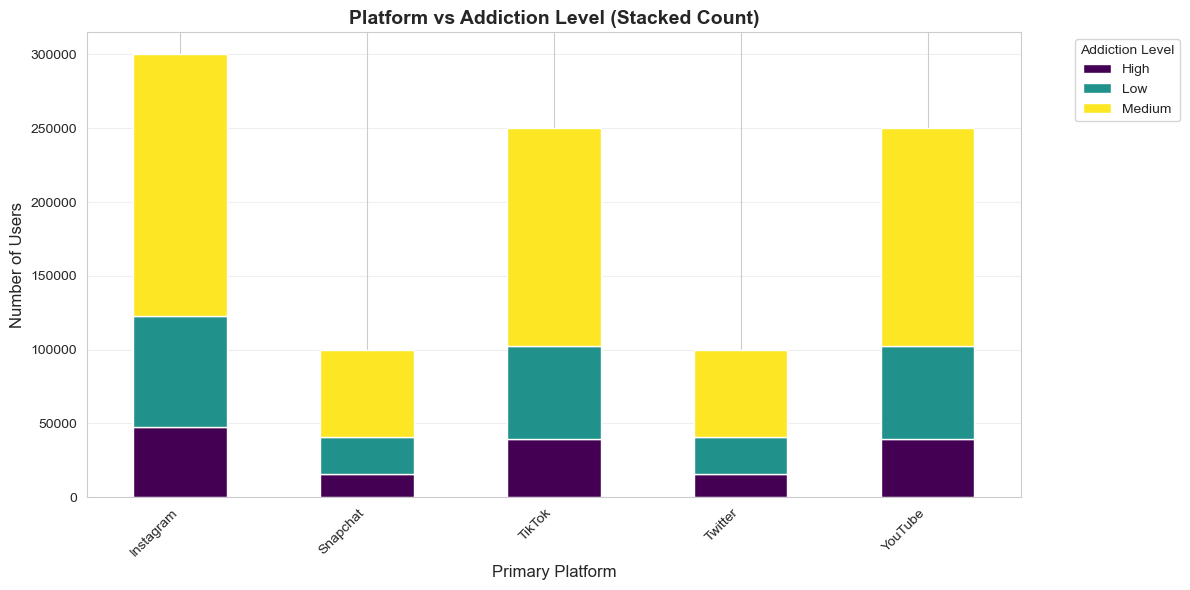

✓ Saved: C:\Users\patil\output\RQ3_Figure2_Grouped_BarChart.png


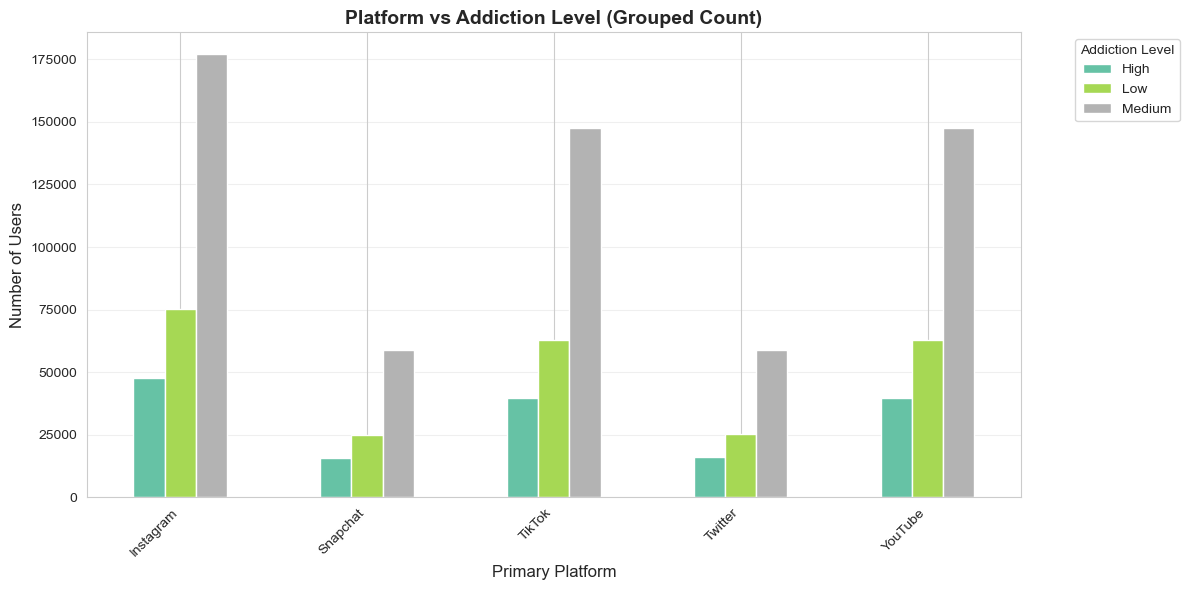

✓ Saved: C:\Users\patil\output\RQ3_Figure3_Heatmap.png


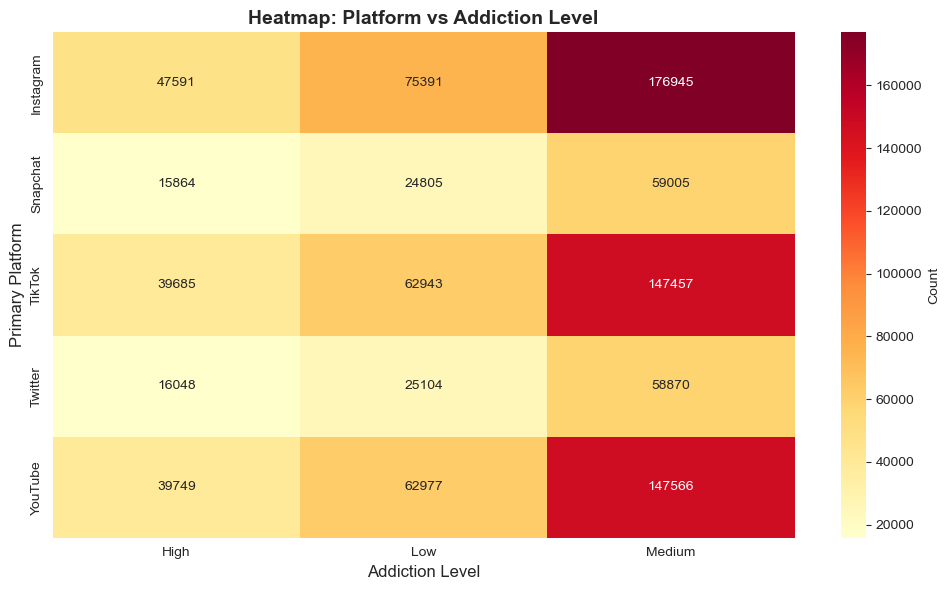

✓ Saved: C:\Users\patil\output\RQ3_Figure4_Percentage_Stacked.png


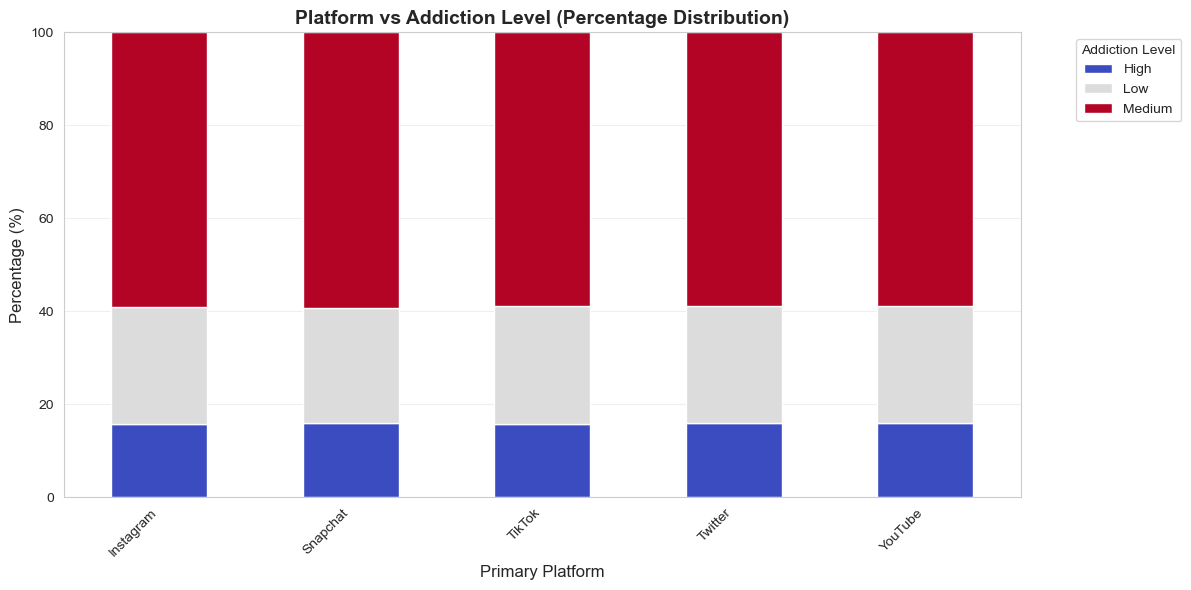

✓ Saved: C:\Users\patil\output\RQ3_Figure5_Pie_Charts.png


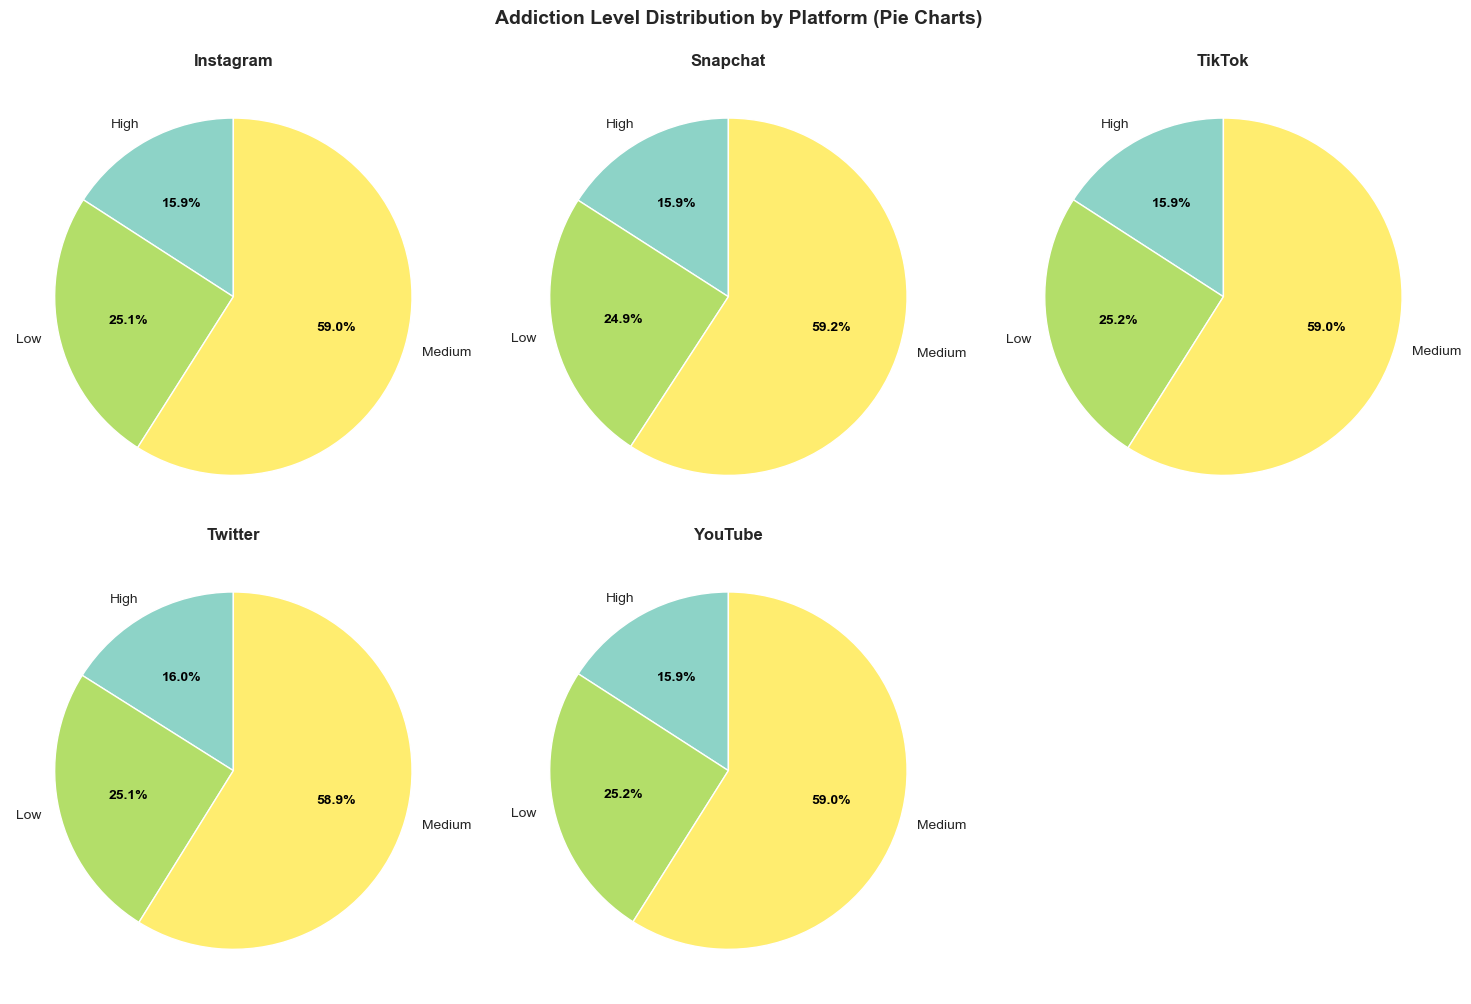


ANALYSIS COMPLETE!

Output files saved to: C:\Users\patil\output

Generated Files:
  • CSV Tables:
    - RQ3_Crosstab_Platform_Addiction.csv
    - RQ3_Normalized_Percentages.csv
    - RQ3_Summary_Statistics.csv
  • Visualizations:
    - RQ3_Figure1_Stacked_BarChart.png
    - RQ3_Figure2_Grouped_BarChart.png
    - RQ3_Figure3_Heatmap.png
    - RQ3_Figure4_Percentage_Stacked.png
    - RQ3_Figure5_Pie_Charts.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Set paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "genz_social_media_usage_1M.csv"
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 80)
print("RQ3: Platform vs Addiction Level Analysis")
print("=" * 80)

# Load data
try:
    df = pd.read_csv('genz_social_media_usage_1Million.csv')
    print(f"\n✓ Data loaded successfully: {len(df)} records")
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    raise

# Check for required columns
required_cols = ["primary_platform", "addiction_level"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"ERROR: Missing columns: {missing_cols}")
    print(f"Available columns: {df.columns.tolist()}")
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"✓ Required columns found: {required_cols}")

# ============================================================================
# CROSSTAB ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("1. CROSS-TABULATION: Platform vs Addiction Level")
print("=" * 80)

# Create crosstab
crosstab_table = pd.crosstab(
    df["primary_platform"], 
    df["addiction_level"],
    margins=True  # Add totals
)

print("\nCrosstab Table:")
print(crosstab_table)

# Save crosstab to CSV
crosstab_path = OUTPUT_DIR / "RQ3_Crosstab_Platform_Addiction.csv"
crosstab_table.to_csv(crosstab_path)
print(f"\n✓ Crosstab saved to: {crosstab_path}")

# ============================================================================
# NORMALIZED PERCENTAGES
# ============================================================================
print("\n" + "=" * 80)
print("2. PERCENTAGE DISTRIBUTION (Row-wise)")
print("=" * 80)

# Create normalized table (percentages by platform)
crosstab_normalized = pd.crosstab(
    df["primary_platform"],
    df["addiction_level"],
    normalize='index'
) * 100

print("\nPercentage Distribution (%):")
print(crosstab_normalized.round(2))

# Save normalized table
normalized_path = OUTPUT_DIR / "RQ3_Normalized_Percentages.csv"
crosstab_normalized.to_csv(normalized_path)
print(f"\n✓ Normalized percentages saved to: {normalized_path}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("3. SUMMARY STATISTICS")
print("=" * 80)

summary_stats = pd.DataFrame({
    'Platform': crosstab_table.index[:-1],
    'Total_Users': crosstab_table.iloc[:-1, -1].values,
    'Addiction_Percentage': (
        crosstab_normalized[crosstab_normalized.columns[-1]].round(2)
    ).values
})

print("\nSummary Statistics:")
print(summary_stats)

summary_path = OUTPUT_DIR / "RQ3_Summary_Statistics.csv"
summary_stats.to_csv(summary_path, index=False)
print(f"\n✓ Summary statistics saved to: {summary_path}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("4. GENERATING VISUALIZATIONS")
print("=" * 80)

# Remove 'All' row for plotting
plot_data = crosstab_table.iloc[:-1, :-1]

# Figure 1: Stacked Bar Chart
fig1, ax1 = plt.subplots(figsize=(12, 6))
plot_data.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis')
ax1.set_title('Platform vs Addiction Level (Stacked Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Primary Platform', fontsize=12)
ax1.set_ylabel('Number of Users', fontsize=12)
ax1.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig1_path = OUTPUT_DIR / "RQ3_Figure1_Stacked_BarChart.png"
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig1_path}")
plt.show()

# Figure 2: Grouped Bar Chart
fig2, ax2 = plt.subplots(figsize=(12, 6))
plot_data.plot(kind='bar', ax=ax2, colormap='Set2')
ax2.set_title('Platform vs Addiction Level (Grouped Count)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Primary Platform', fontsize=12)
ax2.set_ylabel('Number of Users', fontsize=12)
ax2.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig2_path = OUTPUT_DIR / "RQ3_Figure2_Grouped_BarChart.png"
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig2_path}")
plt.show()

# Figure 3: Heatmap
fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.heatmap(plot_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_title('Heatmap: Platform vs Addiction Level', fontsize=14, fontweight='bold')
ax3.set_xlabel('Addiction Level', fontsize=12)
ax3.set_ylabel('Primary Platform', fontsize=12)
plt.tight_layout()
fig3_path = OUTPUT_DIR / "RQ3_Figure3_Heatmap.png"
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig3_path}")
plt.show()

# Figure 4: Normalized Stacked Bar (Percentages)
fig4, ax4 = plt.subplots(figsize=(12, 6))
crosstab_normalized.plot(kind='bar', stacked=True, ax=ax4, colormap='coolwarm')
ax4.set_title('Platform vs Addiction Level (Percentage Distribution)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Primary Platform', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.set_ylim([0, 100])
ax4.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig4_path = OUTPUT_DIR / "RQ3_Figure4_Percentage_Stacked.png"
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig4_path}")
plt.show()

# Figure 5: Pie Charts for each Platform
platforms = plot_data.index
num_platforms = len(platforms)
cols = 3
rows = (num_platforms + cols - 1) // cols

fig5, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for idx, platform in enumerate(platforms):
    ax = axes[idx]
    data = plot_data.loc[platform]
    colors = plt.cm.Set3(np.linspace(0, 1, len(data)))
    wedges, texts, autotexts = ax.pie(
        data, 
        labels=data.index, 
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )
    ax.set_title(f'{platform}', fontsize=12, fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')

# Hide empty subplots
for idx in range(len(platforms), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Addiction Level Distribution by Platform (Pie Charts)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig5_path = OUTPUT_DIR / "RQ3_Figure5_Pie_Charts.png"
plt.savefig(fig5_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig5_path}")
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nOutput files saved to: {OUTPUT_DIR}")
print("\nGenerated Files:")
print(f"  • CSV Tables:")
print(f"    - {crosstab_path.name}")
print(f"    - {normalized_path.name}")
print(f"    - {summary_path.name}")
print(f"  • Visualizations:")
print(f"    - {fig1_path.name}")
print(f"    - {fig2_path.name}")
print(f"    - {fig3_path.name}")
print(f"    - {fig4_path.name}")
print(f"    - {fig5_path.name}")
print("=" * 80)